## SMS Spam Classifier

### This project focuses on analyzing an SMS dataset and building a machine learning model to classify messages as spam or ham (not spam).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('sms_dataset_.xls')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

## Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
# Percentage of null value in each features
df.isnull().sum()/df.shape[0]*100

v1             0.000000
v2             0.000000
Unnamed: 2    99.102656
Unnamed: 3    99.784637
Unnamed: 4    99.892319
dtype: float64

In [6]:
# Dropping last three columns
df = df.iloc[:,0:2]
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [7]:
# Change the features name
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [8]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
# Encoding the target variable
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

In [11]:
df

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [12]:
# Check duplicate row
df.duplicated().sum()

np.int64(403)

In [13]:
# Remove duplicate
df = df.drop_duplicates(keep='first')

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# Total rows = 5572
# Duplicate rows = 403
5572-403

5169

In [16]:
df.shape

(5169, 2)

## EDA (Exploratory Data Analysis)

In [17]:
# How many spam and not spam sms are their
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

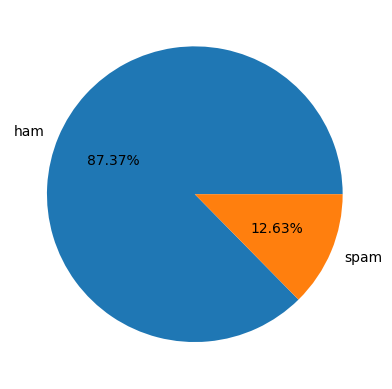

In [18]:
# Ploting a pie chart for the percentage distribution of target
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f%%')
plt.show()

In [19]:
# nltk :- Natural language tool kit 
import nltk

In [20]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aman\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
# Counting the number of character in an sms
df['num_character']=df['text'].apply(len)

In [23]:
df

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [24]:
# Word Tokenize means; break a sentence into a word
# Example
nltk.word_tokenize('Python NumPy Pandas Matplotlib Seaborn')

['Python', 'NumPy', 'Pandas', 'Matplotlib', 'Seaborn']

In [25]:
# Counting the number of words in an sms
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [26]:
df.head()

,target,text,num_character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [27]:
# Sentence Tokenize ; break the sentence
# Example
nltk.sent_tokenize('Hello how are you ? I am fine')

['Hello how are you ?', 'I am fine']

In [28]:
# Check the length of tokenize sentence
# Example
len(nltk.sent_tokenize('Hello how are you ? I am fine'))

2

In [29]:
# Counting the number of sentence in an sms
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [30]:
df.head()

,target,text,num_character,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [31]:
df.iloc[:,2:].describe()

,num_character,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [32]:
# ham message
df[df['target']==0].iloc[:,2:].describe()

,num_character,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


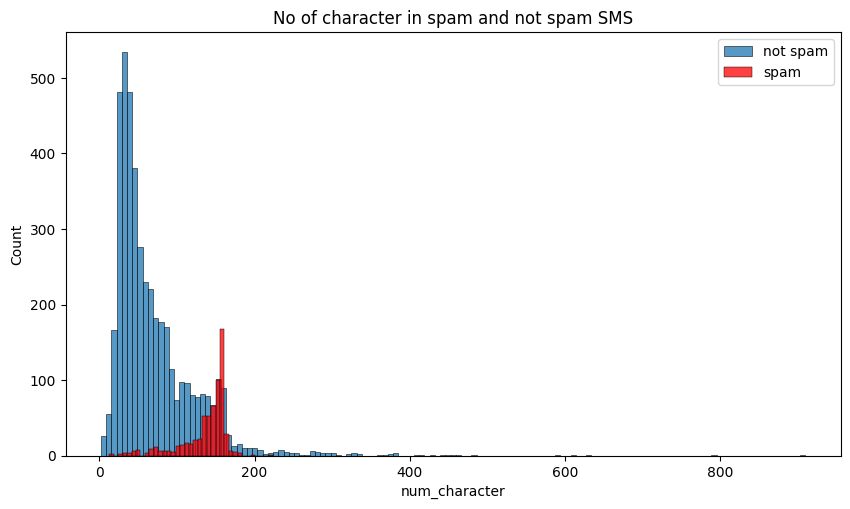

In [33]:
plt.figure(figsize=(10,5.5))
plt.title('No of character in spam and not spam SMS')
sns.histplot(df[df['target']==0].iloc[:,2],label='not spam')
sns.histplot(df[df['target']==1].iloc[:,2],label='spam',color='red')
plt.legend()
plt.show()

In [34]:
# In a not spam messages has use a more character as comparision to spam message.
# It means spam message has use less character.

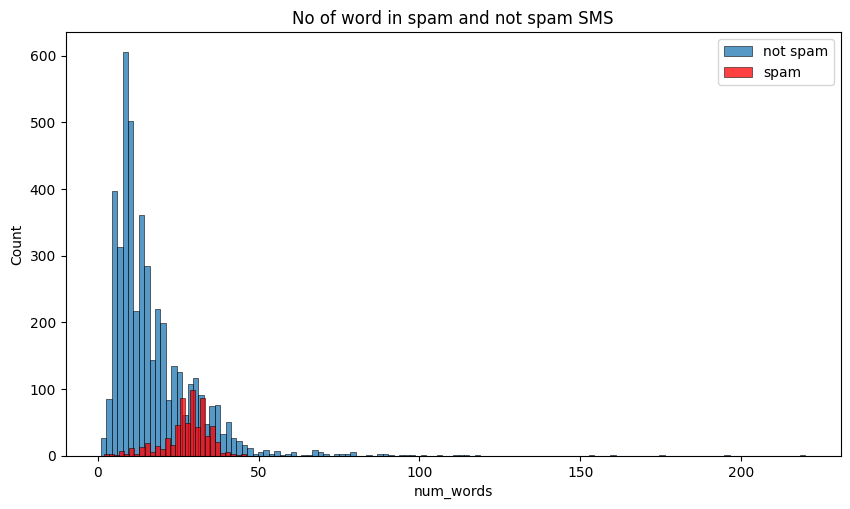

In [35]:
plt.figure(figsize=(10,5.5))
plt.title('No of word in spam and not spam SMS')
sns.histplot(df[df['target']==0].iloc[:,3],label='not spam')
sns.histplot(df[df['target']==1].iloc[:,3],label='spam',color='red')
plt.legend()
plt.show()

In [36]:
# In a not spam messages has use a more words as comparision to spam message.
# It means spam message has use less words.

In [37]:
num_rows = df.select_dtypes(include=np.number)
num_rows

,target,num_character,num_words,num_sentences
0,0,111,24,2
1,0,29,8,2
2,1,155,37,2
3,0,49,13,1
4,0,61,15,1
...,...,...,...,...
5567,1,161,35,4
5568,0,37,9,1
5569,0,57,15,2
5570,0,125,27,1


<Axes: >

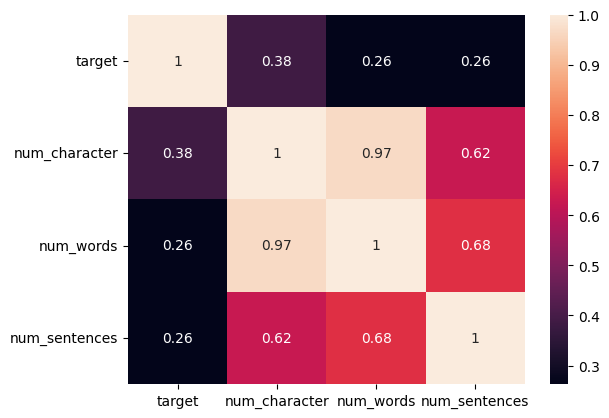

In [38]:
sns.heatmap(num_rows.corr(),annot=True)

In [39]:
# Correlation of target and num_character is 0.38
# It means, if we increase the number of words then the corelation tendency is approaches to 1,
# num_character has high multicollinearity, 
# So I will select only 1 column

## Data Preprocessing
    Lower case
    Tolenization
    Removing Special Characters
    Removing stop words & punctuations
    Stemming (word are converted into root or simple form )

In [40]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [41]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [42]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [43]:
# Stemming (word converted to simple or root form)
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('joinned')

'join'

In [44]:
# Example of stemming
ps.stem('eating')

'eat'

In [45]:
# Example of stemming
ps.stem('running')

'run'

In [46]:
def transform_text(text):
    text=text.lower()     # Converting in lower case
    print(text)
    text=nltk.word_tokenize(text)        # splitting into word
    print(text)

    # removing special character
    L = []
    for i in text:
        if i.isalnum():
            L.append(i)
    print(L)

# Removing stop words and punctuation marks
    text=L.copy()
    L.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            L.append(i)
    print(L)

# Applying stemming
    text=L.copy()
    L.clear()
    for i in text:
        L.append(ps.stem(i))
    print(L)

    return " ".join(L)

In [47]:
# Example
transform_text('hello i am WALKING ? Are you ^ joining me.')

hello i am walking ? are you ^ joining me.
['hello', 'i', 'am', 'walking', '?', 'are', 'you', '^', 'joining', 'me', '.']
['hello', 'i', 'am', 'walking', 'are', 'you', 'joining', 'me']
['hello', 'walking', 'joining']
['hello', 'walk', 'join']


'hello walk join'

In [48]:
# Example
transform_text('i am enjoying this FDP on Machine Learning ? How about you.')

i am enjoying this fdp on machine learning ? how about you.
['i', 'am', 'enjoying', 'this', 'fdp', 'on', 'machine', 'learning', '?', 'how', 'about', 'you', '.']
['i', 'am', 'enjoying', 'this', 'fdp', 'on', 'machine', 'learning', 'how', 'about', 'you']
['enjoying', 'fdp', 'machine', 'learning']
['enjoy', 'fdp', 'machin', 'learn']


'enjoy fdp machin learn'

In [49]:
# Applying text transform 
df['transformed_text']=df['text'].apply(transform_text)

go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat...
['go', 'until', 'jurong', 'point', ',', 'crazy', '..', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', '...', 'cine', 'there', 'got', 'amore', 'wat', '...']
['go', 'until', 'jurong', 'point', 'crazy', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'there', 'got', 'amore', 'wat']
['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'wat']
['go', 'jurong', 'point', 'crazi', 'avail', 'bugi', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amor', 'wat']
ok lar... joking wif u oni...
['ok', 'lar', '...', 'joking', 'wif', 'u', 'oni', '...']
['ok', 'lar', 'joking', 'wif', 'u', 'oni']
['ok', 'lar', 'joking', 'wif', 'u', 'oni']
['ok', 'lar', 'joke', 'wif', 'u', 'oni']
free entry in 2 a wkly comp to win fa cup final tkts 21st may 2

In [50]:
df.head()

,target,text,num_character,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [51]:
from wordcloud import WordCloud

In [52]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='black')

In [53]:
# Filter Spam SMS
df[df['target']==1]

,target,text,num_character,num_words,num_sentences,transformed_text
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
5,1,FreeMsg Hey there darling it's been 3 week's n...,148,39,4,freemsg hey darl 3 week word back like fun sti...
8,1,WINNER!! As a valued network customer you have...,158,32,5,winner valu network custom select receivea pri...
9,1,Had your mobile 11 months or more? U R entitle...,154,31,3,mobil 11 month u r entitl updat latest colour ...
11,1,"SIX chances to win CASH! From 100 to 20,000 po...",136,31,3,six chanc win cash 100 pound txt csh11 send co...
...,...,...,...,...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...,90,18,3,want explicit sex 30 sec ring 02073162414 cost...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,160,38,6,ask 3mobil 0870 chatlin inclu free min india c...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...,160,35,5,contract mobil 11 mnth latest motorola nokia e...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...,147,30,1,remind o2 get pound free call credit detail gr...


In [54]:
df[df['target']==1]['transformed_text'] 

2       free entri 2 wkli comp win fa cup final tkt 21...
5       freemsg hey darl 3 week word back like fun sti...
8       winner valu network custom select receivea pri...
9       mobil 11 month u r entitl updat latest colour ...
11      six chanc win cash 100 pound txt csh11 send co...
                              ...                        
5537    want explicit sex 30 sec ring 02073162414 cost...
5540    ask 3mobil 0870 chatlin inclu free min india c...
5547    contract mobil 11 mnth latest motorola nokia e...
5566    remind o2 get pound free call credit detail gr...
5567    2nd time tri 2 contact u pound prize 2 claim e...
Name: transformed_text, Length: 653, dtype: object

In [55]:
# Corpus ; means concate all data
# Concate all data
df[df['target']==1]['transformed_text'].str.cat(sep=" ")

'free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18 freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030 six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18 xxxmobilemovieclub use credit click wap link next txt messag click http england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq thank subscript rington uk mobil charg pleas confirm repli ye repli charg 07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow sm ac sptv new jersey devil detroit red w

In [56]:
# Frequently used word
# Most repeated text are shows in bigger size

In [57]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [58]:
# For Spam sms
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

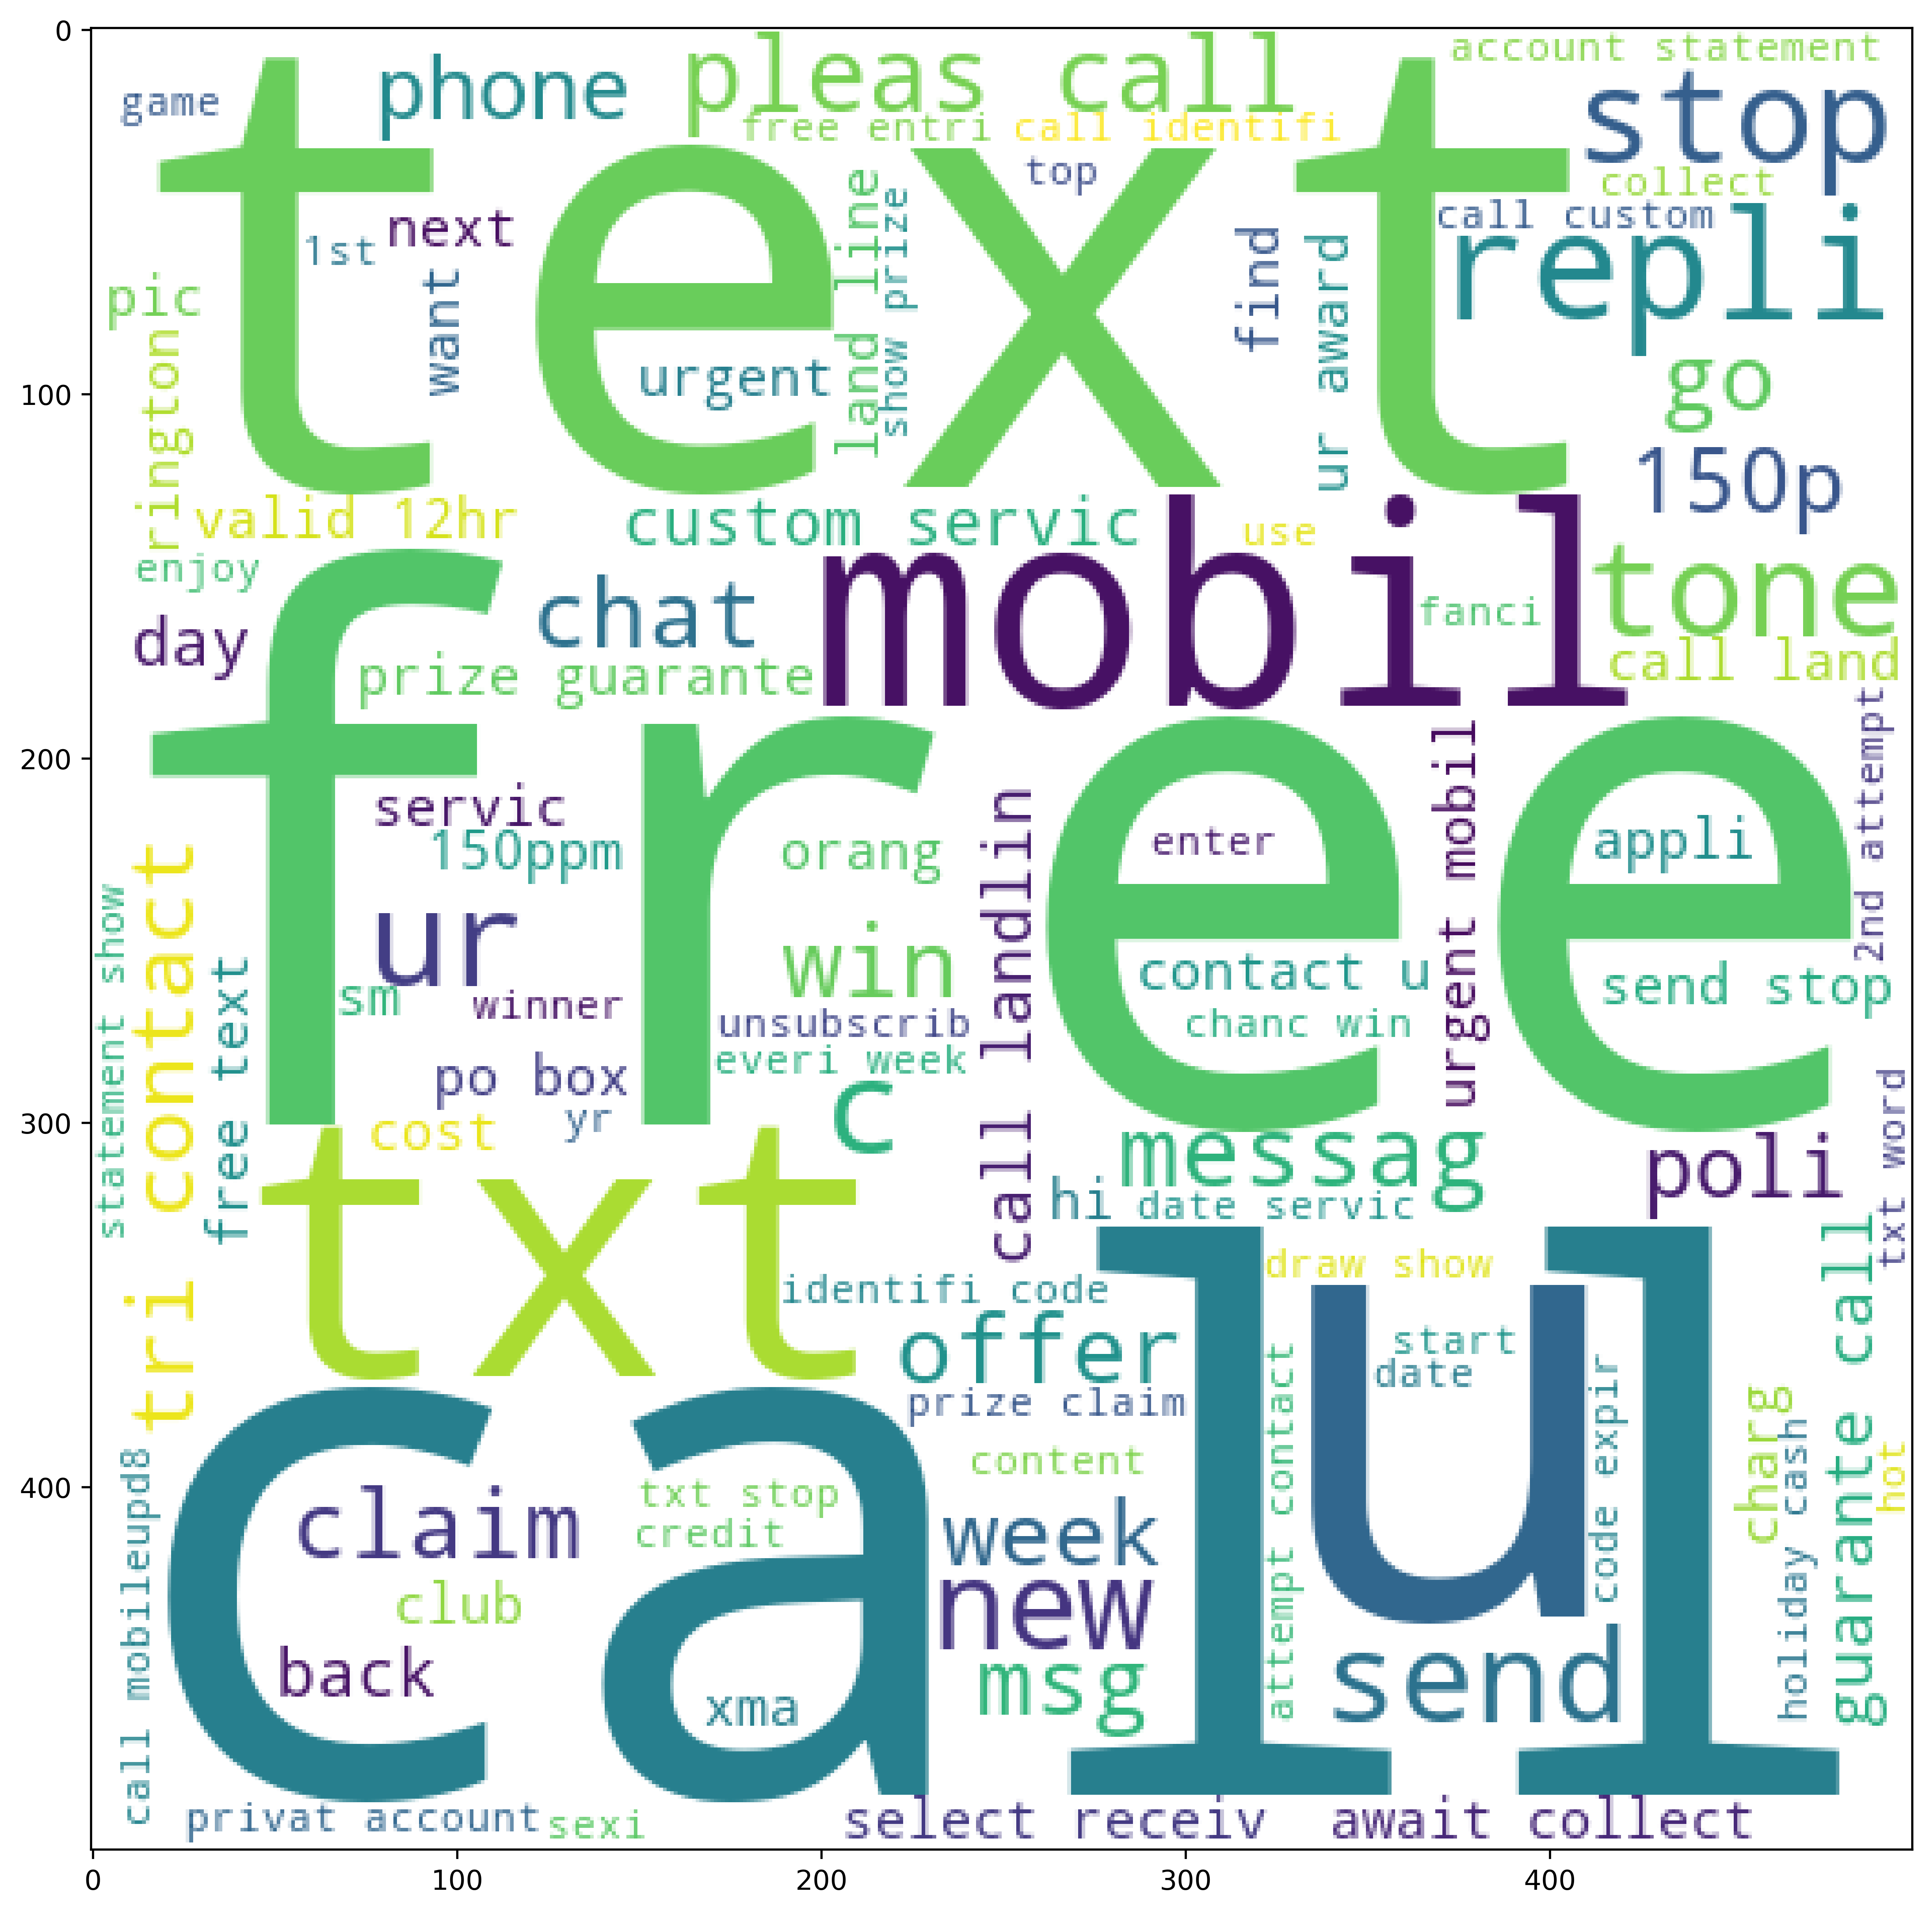

In [59]:
# Wordcloud for spam sms
plt.figure(figsize=(12,12),dpi=500)
plt.imshow(spam_wc)

In [60]:
# For hmas (Not Spam sms)
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

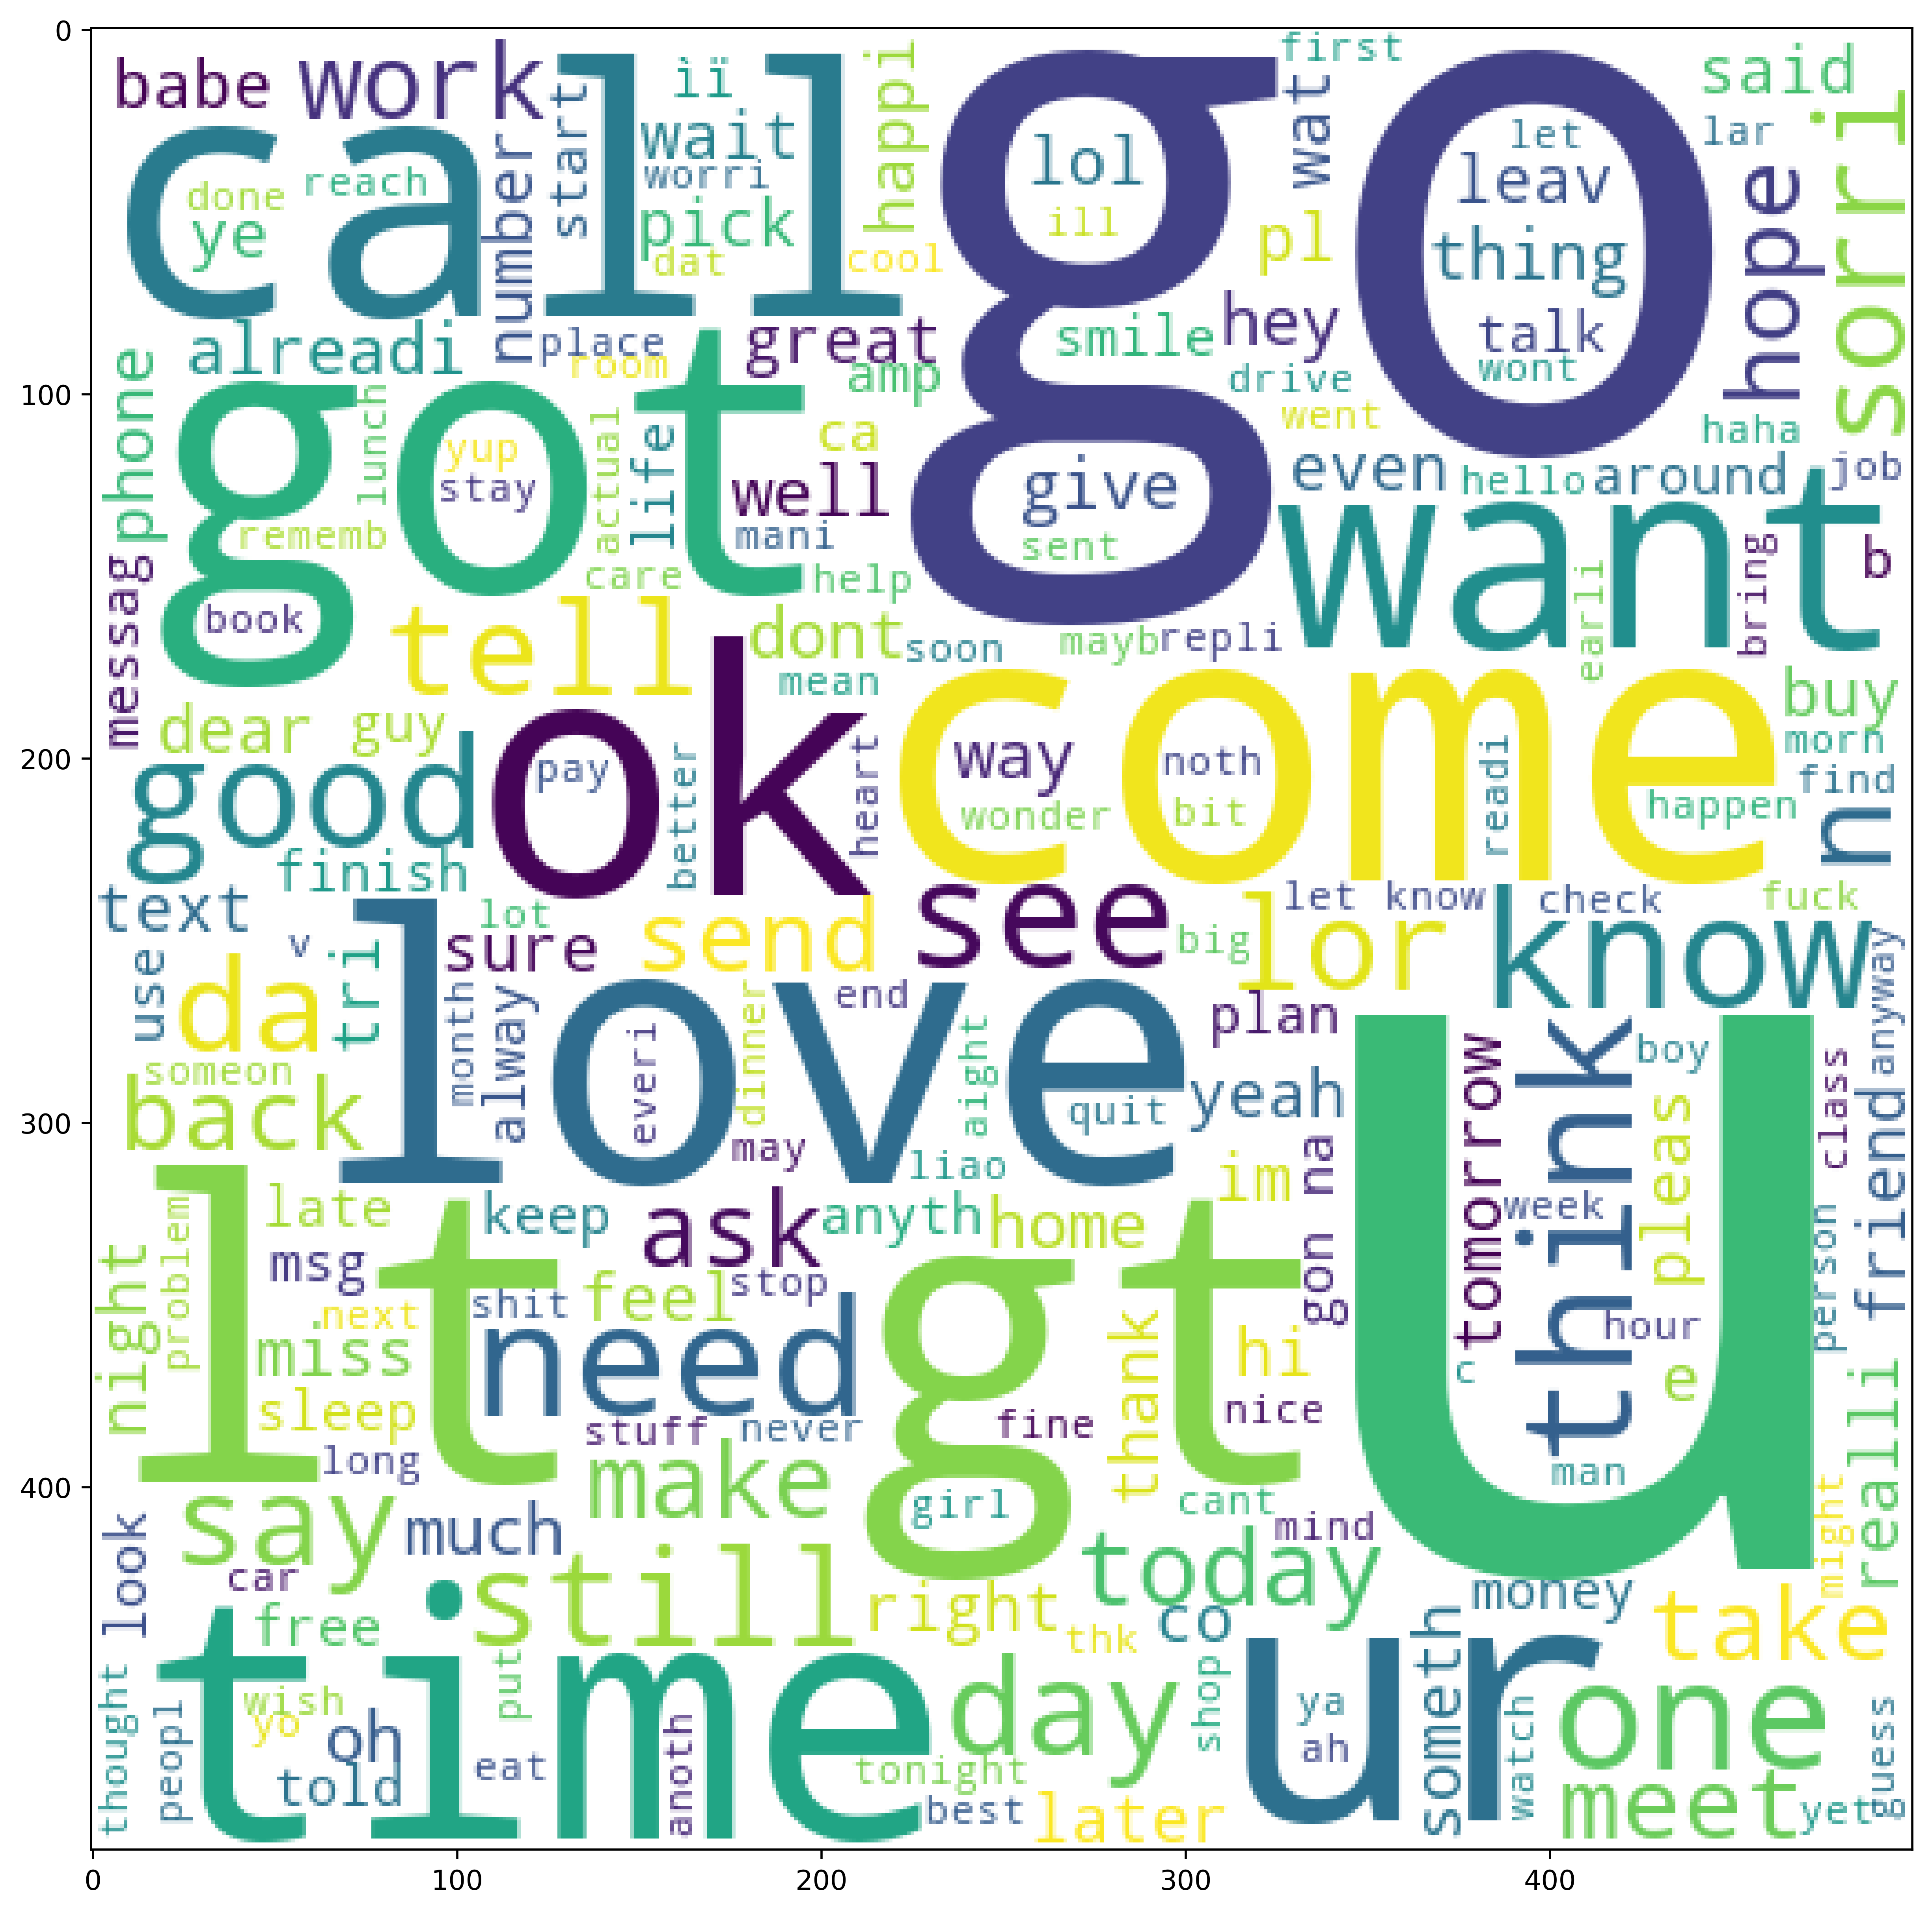

In [61]:
# Wordcloud for not spam sms
plt.figure(figsize=(12,12),dpi=500)
plt.imshow(ham_wc)

In [62]:
# Displaying the top 30 words in spam sms

In [63]:
df[df['target']==1]['transformed_text'].tolist()

['free entri 2 wkli comp win fa cup final tkt 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18',
 'freemsg hey darl 3 week word back like fun still tb ok xxx std chg send rcv',
 'winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour',
 'mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030',
 'six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info',
 'urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18',
 'xxxmobilemovieclub use credit click wap link next txt messag click http',
 'england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq',
 'thank subscript rington uk mobil charg pleas confirm repli ye repli charg',
 '07732584351 rodger burn msg tri call repli sm free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow',
 '

In [64]:
# Most repeated word
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
print(spam_corpus)

['free', 'entri', '2', 'wkli', 'comp', 'win', 'fa', 'cup', 'final', 'tkt', '21st', 'may', 'text', 'fa', '87121', 'receiv', 'entri', 'question', 'std', 'txt', 'rate', 'c', 'appli', '08452810075over18', 'freemsg', 'hey', 'darl', '3', 'week', 'word', 'back', 'like', 'fun', 'still', 'tb', 'ok', 'xxx', 'std', 'chg', 'send', 'rcv', 'winner', 'valu', 'network', 'custom', 'select', 'receivea', 'prize', 'reward', 'claim', 'call', 'claim', 'code', 'kl341', 'valid', '12', 'hour', 'mobil', '11', 'month', 'u', 'r', 'entitl', 'updat', 'latest', 'colour', 'mobil', 'camera', 'free', 'call', 'mobil', 'updat', 'co', 'free', '08002986030', 'six', 'chanc', 'win', 'cash', '100', 'pound', 'txt', 'csh11', 'send', 'cost', '6day', 'tsandc', 'appli', 'repli', 'hl', '4', 'info', 'urgent', '1', 'week', 'free', 'membership', 'prize', 'jackpot', 'txt', 'word', 'claim', '81010', 'c', 'lccltd', 'pobox', '4403ldnw1a7rw18', 'xxxmobilemovieclub', 'use', 'credit', 'click', 'wap', 'link', 'next', 'txt', 'messag', 'click',

In [65]:
# For counting the word
from collections import Counter

In [66]:
spam_df = pd.DataFrame(Counter(spam_corpus).most_common()).rename(columns={0:'words',1:'count'})
spam_df

,words,count
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
...,...,...
2217,shit,1
2218,bailiff,1
2219,hous,1
2220,087187272008,1


In [67]:
spam_df.head(30)

,words,count
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


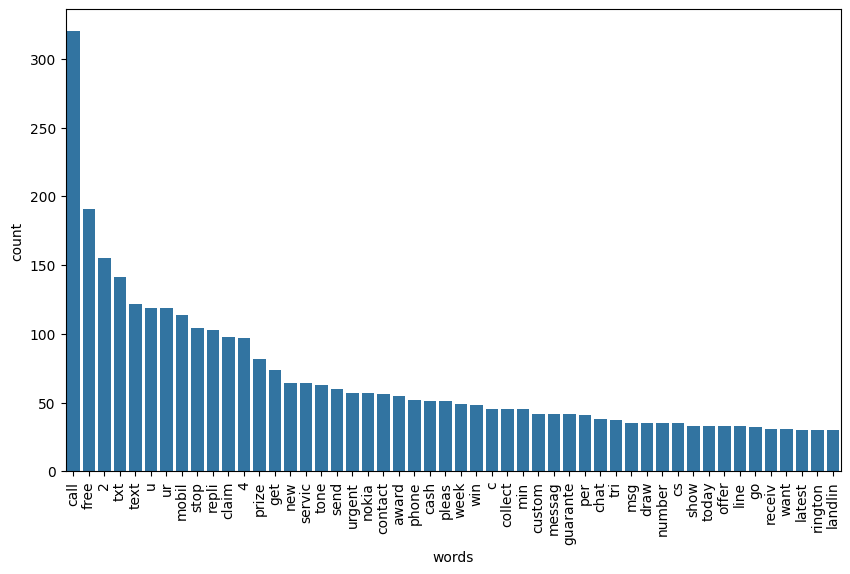

In [68]:
# Ploting a bar graph for most repeated word in spam sms
plt.figure(figsize=(10,6))
sns.barplot(x='words',y='count',data=spam_df.head(50))
plt.xticks(rotation='vertical')
plt.show()

In [69]:
# For ham (Not Spam SMS)

In [70]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
print(ham_corpus)

['go', 'jurong', 'point', 'crazi', 'avail', 'bugi', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amor', 'wat', 'ok', 'lar', 'joke', 'wif', 'u', 'oni', 'u', 'dun', 'say', 'earli', 'hor', 'u', 'c', 'alreadi', 'say', 'nah', 'think', 'goe', 'usf', 'live', 'around', 'though', 'even', 'brother', 'like', 'speak', 'treat', 'like', 'aid', 'patent', 'per', 'request', 'mell', 'oru', 'minnaminungint', 'nurungu', 'vettam', 'set', 'callertun', 'caller', 'press', '9', 'copi', 'friend', 'callertun', 'gon', 'na', 'home', 'soon', 'want', 'talk', 'stuff', 'anymor', 'tonight', 'k', 'cri', 'enough', 'today', 'search', 'right', 'word', 'thank', 'breather', 'promis', 'wont', 'take', 'help', 'grant', 'fulfil', 'promis', 'wonder', 'bless', 'time', 'date', 'sunday', 'oh', 'k', 'watch', 'eh', 'u', 'rememb', '2', 'spell', 'name', 'ye', 'v', 'naughti', 'make', 'v', 'wet', 'fine', 'thatåõ', 'way', 'u', 'feel', 'thatåõ', 'way', 'gota', 'b', 'serious', 'spell', 'name', 'go', 'tri', '2', 'month', 'ha', 

In [71]:
ham_df = pd.DataFrame(Counter(ham_corpus).most_common()).rename(columns={0:'word',1:'count'})
ham_df

,word,count
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
...,...,...
5385,nmde,1
5386,dump,1
5387,heap,1
5388,salesman,1


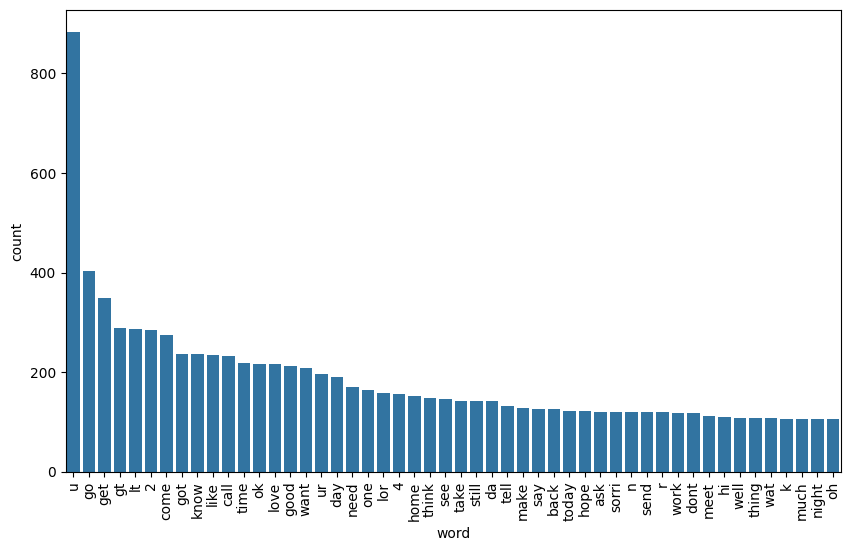

In [72]:
# Ploting a bar graph for most repeated word in not spam sms
plt.figure(figsize=(10,6))
sns.barplot(x='word',y='count',data=ham_df.head(50))
plt.xticks(rotation='vertical')
plt.show()

## Feature Engineering

In [73]:
# Tf-idf  ; Term Frequency (Probability of word) and convert in numerical form
 # Vectorization using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

In [74]:
# Splitting the dataset into features and target variable

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
x=tfidf.fit_transform(df['transformed_text']).toarray()
x

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [77]:
x.shape

(5169, 3000)

In [78]:
y=df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [79]:
# Train-Test Split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [80]:
# Model Building
# Model Training & Evaluation

In [81]:
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,recall_score
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [82]:
svc = SVC()
knc = KNeighborsClassifier()
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB(alpha=0.2,fit_prior=False)
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression()
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [83]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'GNB' : gnb,
    'MNB': mnb,
    'BNB': bnb,
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [84]:
clfs.items()

dict_items([('SVC', SVC()), ('KN', KNeighborsClassifier()), ('GNB', GaussianNB()), ('MNB', MultinomialNB()), ('BNB', BernoulliNB(alpha=0.2, fit_prior=False)), ('DT', DecisionTreeClassifier(max_depth=5)), ('LR', LogisticRegression()), ('RF', RandomForestClassifier(n_estimators=50, random_state=2)), ('AdaBoost', AdaBoostClassifier(random_state=2)), ('BgC', BaggingClassifier(n_estimators=50, random_state=2)), ('ETC', ExtraTreesClassifier(n_estimators=50, random_state=2)), ('GBDT', GradientBoostingClassifier(n_estimators=50, random_state=2)), ('xgb', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max

In [85]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    # clf.fit(x_resampled,y_resampled)
    y_pred_test = clf.predict(x_test)
    y_pred_train = clf.predict(x_train)

    accuracy_test = accuracy_score(y_test,y_pred_test)
    accuracy_train = accuracy_score(y_train,y_pred_train)
    precision_scores_train = precision_score(y_train,y_pred_train)
    precision_scores_test = precision_score(y_test,y_pred_test)
    recall_score_train = recall_score(y_train,y_pred_train)
    recall_score_test = recall_score(y_test,y_pred_test)
    confusion_matrix_test = confusion_matrix(y_test,y_pred_test)
    confusion_matrix_train = confusion_matrix(y_train,y_pred_train)
    
    
    return accuracy_train,accuracy_test,precision_scores_train,precision_scores_test,recall_score_train,recall_score_test,confusion_matrix_train,confusion_matrix_test

In [86]:
for name,clf in clfs.items():
    
    accuracy_train,accuracy_test,precision_score_train,precision_score_test,recall_score_train,recall_score_test,confusion_matrix_train,confusion_matrix_test = train_classifier(clf, x_train,y_train,x_test,y_test)
    
    print("For ",name)
    print("Training Accuracy - ",accuracy_train)
    print("Testing Accuracy - ",accuracy_test)
    print("Precision Score Training ",precision_score_train)
    print("Precision Score Testing ",precision_score_test)
    print("Recall Score Training ",recall_score_train)
    print("Recall Score Testing ",recall_score_test)
    print("Confusion Matrix Training \n",confusion_matrix_train)
    print("Confusion Matrix Testing \n",confusion_matrix_test)
    print()

For  SVC
Training Accuracy -  0.9963724304715841
Testing Accuracy -  0.9729206963249516
Precision Score Training  1.0
Precision Score Testing  0.9824561403508771
Recall Score Training  0.970873786407767
Recall Score Testing  0.8115942028985508
Confusion Matrix Training 
 [[3620    0]
 [  15  500]]
Confusion Matrix Testing 
 [[894   2]
 [ 26 112]]

For  KN
Training Accuracy -  0.9257557436517533
Testing Accuracy -  0.9052224371373307
Precision Score Training  1.0
Precision Score Testing  1.0
Recall Score Training  0.40388349514563104
Recall Score Testing  0.2898550724637681
Confusion Matrix Training 
 [[3620    0]
 [ 307  208]]
Confusion Matrix Testing 
 [[896   0]
 [ 98  40]]

For  GNB
Training Accuracy -  0.8931076178960097
Testing Accuracy -  0.8694390715667312
Precision Score Training  0.5381400208986415
Precision Score Testing  0.5068493150684932
Recall Score Training  1.0
Recall Score Testing  0.8043478260869565
Confusion Matrix Training 
 [[3178  442]
 [   0  515]]
Confusion Matr

In [87]:
# Bernoulli Naive Bayes achieved the best performance with 99.03% accuracy, perfect precision, and near-perfect recall.

In [88]:
# Saving the best performance model as Bernoulli Naive Bayes

In [89]:
import pickle

In [90]:
pickle.dump(tfidf,open('sms_vectorizer_tfidf.pkl','wb'))
pickle.dump(bnb,open('sms_model_bnb.pkl','wb'))